In [16]:
import sys
import os
sys.path.append(os.path.abspath("../"))  # or "../../" depending on location

In [17]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from utils.likelihood import *
from utils.formate_matrix_toMLData import *
from models.model_0929 import *
np.set_printoptions(suppress=True)
import seaborn as sns

import time

Registered Font Name: Open Sans


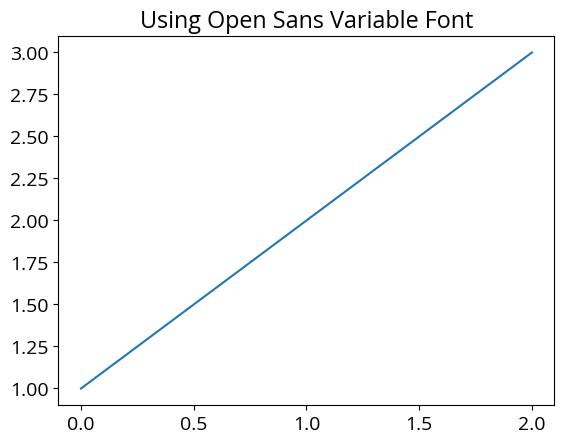

In [18]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
plt.rcParams["font.size"] = 14
font_path = "/Users/yamashitanatsuki/Library/Fonts/OpenSans-VariableFont_wdth,wght.ttf"

# フォントを Matplotlib に登録
fm.fontManager.addfont(font_path)

# フォント名取得（登録後の認識名を確認）
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()
print("Registered Font Name:", font_name)

# rcParams に反映
mpl.rcParams['font.family'] = font_name
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.plot([1,2,3])
plt.title("Using Open Sans Variable Font")
plt.show()

In [19]:
device = torch.device("cpu")
model = DeepSets_varSets_forDiagnel(device=device).to(device)
model.load_state_dict(torch.load("../model_weights/mixed_distribution/mixed_0929.pth", map_location=device))
model.eval()

/var/folders/k3/b1t1gjg12pg0ycfdgpm2k7g00000gn/T/ipykernel_59903/3267676366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../model_we

DeepSets_varSets_forDiagnel(
  (embedding): Embedding(5, 16, padding_idx=0)
  (fc1): Linear(in_features=33, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.2, inplace=False)
  (att_fc): Linear(in_features=512, out_features=512, bias=True)
  (att_score): Linear(in_features=512, out_features=1, bias=True)
  (out_fc1): Linear(in_features=512, out_features=128, bias=True)
  (out_ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (out_fc2): Linear(in_features=128, out_features=64, bias=True)
  (out_ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (out_fc3): Linear(in_features=64, out_features=3, bias=True)
)

## 実データ（元データセット）読み込み

In [20]:
data_name = "shoban"  

real_data_dir = f"../real_data/{data_name}.csv"
df = pd.read_csv(real_data_dir, delimiter=",")

if data_name == "shoban":
    df = df.rename(columns={'Be(1-4)': "pre", 'Af(1-4)': "post", 'Ins': "time"})
df = df[["pre", "post", "time"]]
state = np.array([df["pre"],df["post"]])
del_t = np.array(df["time"])

data = np.column_stack((state.T,del_t.T))

## 最尤推定の実行

In [22]:
ll = Likelihood_diagonal_exp(data)
time_MLE = []
for i in range(10):
    v = np.random.uniform(-5, 0, size=3)
    print(v)
    t0 = time.time()
    Q = ll.optimize(v)
    t1 = time.time()
    time_MLE.append(t1 - t0)
    print("最尤推定にかかった時間:", t1 - t0, "秒")


formater = formate_dataMatrix()
vec = formater.GetOutputVector_byDiagonal(Q)

[-4.13093768 -1.86914956 -2.0255616 ]
最尤推定にかかった時間: 260.70291209220886 秒
[-3.59067754 -0.38291044 -1.92691286]
最尤推定にかかった時間: 133.19323921203613 秒
[-0.66056634 -4.74090619 -4.529819  ]
最尤推定にかかった時間: 279.6903169155121 秒
[-2.72234249 -4.36767589 -4.3782358 ]
最尤推定にかかった時間: 291.89545917510986 秒
[-3.09616238 -2.64632239 -1.96817703]
最尤推定にかかった時間: 163.0307309627533 秒
[-3.32143586 -4.48405155 -1.88888486]
最尤推定にかかった時間: 187.57588291168213 秒
[-3.15629245 -0.39798308 -4.62788087]
最尤推定にかかった時間: 229.757159948349 秒
[-0.34981408 -3.10077566 -3.64223651]
最尤推定にかかった時間: 236.32253694534302 秒
[-0.69565692 -2.05647394 -3.33010988]


/opt/anaconda3/envs/kisozemi/lib/python3.11/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)


最尤推定にかかった時間: 435.9374189376831 秒
[-2.55346078 -2.23569201 -2.78091798]
最尤推定にかかった時間: 202.13734197616577 秒


In [ ]:
dataset = varSets_Datasets([state],[del_t], [vec])
dataloader = DataLoader(dataset, batch_size=1,shuffle=False,collate_fn=collate_fn)
pred = []
expect = []
time_surrogate = []
for _ in range(10):
    for a, b, c,d in dataloader:
        with torch.no_grad():
            t0_surrogate = time.time()
            out = model(a, b, d)
            t1_surrogate = time.time()
            pred = 1/out
            expect = 1/c
        print(f"output is {out}")
        print(f"target is {c}")
        print(1/out)
        print(1/c)
        print("サロゲートモデルの推論にかかった時間:", t1_surrogate - t0_surrogate, "秒")
        time_surrogate.append(t1_surrogate - t0_surrogate)


output is tensor([[0.0221, 0.1408, 0.1018]])
target is tensor([[0.0219, 0.1364, 0.1015]])
tensor([[45.3290,  7.1021,  9.8203]])
tensor([[45.6287,  7.3335,  9.8489]])
サロゲートモデルの推論にかかった時間: 0.06988310813903809 秒
output is tensor([[0.0221, 0.1408, 0.1018]])
target is tensor([[0.0219, 0.1364, 0.1015]])
tensor([[45.3290,  7.1021,  9.8203]])
tensor([[45.6287,  7.3335,  9.8489]])
サロゲートモデルの推論にかかった時間: 0.045969247817993164 秒
output is tensor([[0.0221, 0.1408, 0.1018]])
target is tensor([[0.0219, 0.1364, 0.1015]])
tensor([[45.3290,  7.1021,  9.8203]])
tensor([[45.6287,  7.3335,  9.8489]])
サロゲートモデルの推論にかかった時間: 0.04152393341064453 秒
output is tensor([[0.0221, 0.1408, 0.1018]])
target is tensor([[0.0219, 0.1364, 0.1015]])
tensor([[45.3290,  7.1021,  9.8203]])
tensor([[45.6287,  7.3335,  9.8489]])
サロゲートモデルの推論にかかった時間: 0.04174494743347168 秒
output is tensor([[0.0221, 0.1408, 0.1018]])
target is tensor([[0.0219, 0.1364, 0.1015]])
tensor([[45.3290,  7.1021,  9.8203]])
tensor([[45.6287,  7.3335,  9.8489]])
サ

In [23]:
calctime_df = pd.DataFrame({"MLE_time": time_MLE, "Surrogate_time": time_surrogate})
calctime_df.to_csv(f"calctime_{data_name}_rundom.csv", index=False)

## subsample Setに対する結果
### subusample Setの読み込み

In [ ]:
data_dir_base = dir_base="/Volumes/TRANSCEND/datas"
EXTERNAL_DATASETS = {
    "n200": {"path": dir_base+"/real_data/shoban/samples_200", "ll_use": False},
    "n400": {"path":dir_base+ "/real_data/shoban/samples_400", "ll_use": False},
    "n600": {"path": dir_base+"/real_data/shoban/samples_600", "ll_use": False},
    "n800": {"path": dir_base+"/real_data/shoban/samples_800", "ll_use": False},
    "n1000": {"path": dir_base+"/real_data/shoban/samples_1000", "ll_use": False},
}

VALID_EXTENSIONS = (".csv", ".txt")
IGNORED_PREFIXES = ("._", ".DS_Store", "Thumbs.db")